# 02: The Capacity Build-Out

**Business question**: How fast is Malaysia actually building data centre capacity, and how concentrated is that build-out in Johor specifically?

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/processed/dcboom.db')
capacity = pd.read_sql_query("SELECT * FROM capacity_trend ORDER BY year", conn)
conn.close()
capacity

,year,malaysia_live_mw,johor_built_mw,johor_building_mw,johor_pipeline_mw,source
0,2019,55.0,NaN,NaN,NaN,"BNM Q3 2025 Bulletin box article, Chart 2 (sou..."
1,2025,784.0,NaN,NaN,NaN,"BNM Q3 2025 Bulletin, preliminary 3Q2025 figure"
2,2026,2055.0,850.0,1800.0,2700.0,National figure: JLL Malaysia data centre mark...


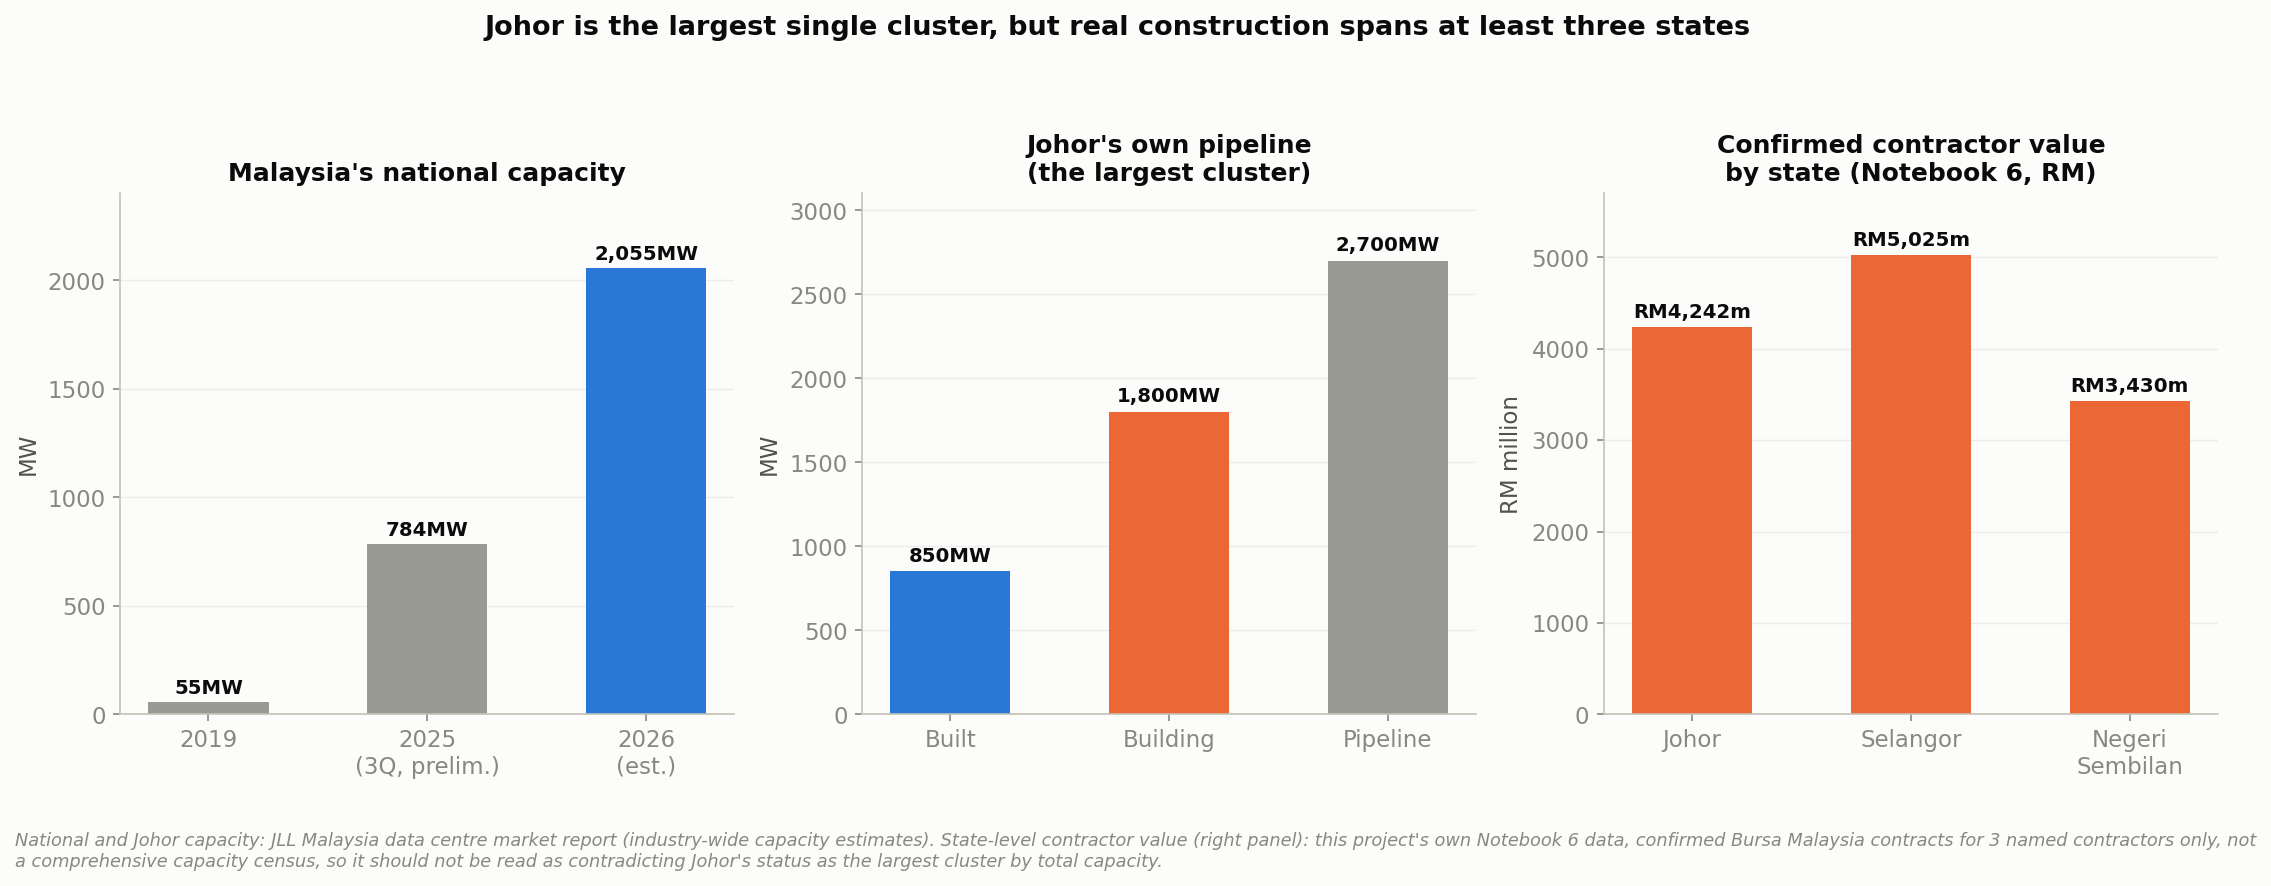

In [2]:
from IPython.display import Image
Image(filename='../outputs/figures/02_capacity_buildout.png')

## Reading the two charts together

Live national capacity went from **55MW (2019) to 784MW (3Q2025, preliminary)**, a 55.6% compound annual growth rate over roughly six years, and is estimated to reach **2,055MW by end-2026**, effectively doubling again in about a year. **[PUBLIC, Bank Negara Malaysia Q3 2025 Bulletin (2019, 2025 figures); JLL Malaysia data centre market report (2026 estimate)]**

Johor's own pipeline shows the same acceleration from a different angle: **850MW already built, 1,800MW under construction, and a further 2,700MW in the pipeline** beyond that, meaning what's already operating in Johor is smaller than either of the next two build-out stages individually. If the full pipeline materialises, Johor alone would account for roughly 60% of Malaysia's projected national capacity by 2030. **[PUBLIC, JLL Malaysia data centre market report]**

This chart answers "how much is being built," but not "how much of it is actually being used." That is a genuinely different question, covered directly in Notebook 3, where TNB's own connection and utilisation data shows a real gap between what has been secured on paper and what is actually drawing power.

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/processed/dcboom.db')
contracts = pd.read_sql_query("SELECT company, location, contract_value_rm_m FROM contractor_contracts", conn)
conn.close()

def state(loc):
    if 'Johor' in loc:
        return 'Johor'
    if 'Selangor' in loc:
        return 'Selangor'
    if 'Negeri Sembilan' in loc:
        return 'Negeri Sembilan'
    return 'Other'

contracts['state'] = contracts['location'].apply(state)
contracts.groupby('state')['contract_value_rm_m'].agg(['count', 'sum']).rename(
    columns={'count': 'confirmed_contracts', 'sum': 'total_rm_m'}
)

,confirmed_contracts,total_rm_m
state,,
Johor,5,4241.60
Negeri Sembilan,2,3430.00
Selangor,4,5024.91


## Where in Malaysia this is actually happening: Johor is the largest, not the only one

**Johor is genuinely the largest single cluster**, with 850MW already built, per an industry-wide capacity estimate covering every operator in the state, and it is the focus of most of this project's other notebooks (1, 7, 10) because of its distinct border-with-Singapore story. But it is not the only place this boom is happening, and this project's own research (Notebook 6) confirms real, substantial hyperscale construction in at least two other states:

- **Selangor**: Elmina Business Park and Bandar Serendah, where this project found confirmed contracts worth **RM5,025 million**.
- **Negeri Sembilan**: Port Dickson, where this project found confirmed contracts worth **RM3,430 million**.
- **Johor** itself also has confirmed contractor activity of **RM4,242 million** in this same dataset.

One important caveat on how to read the table above: it counts only the specific construction contracts this project found from three named contractors (Sunway Construction, Gamuda, IJM). It is **not** a comprehensive capacity census the way Johor's 850MW figure is. So while Selangor's confirmed contract value happens to be slightly higher than Johor's in this particular sample, that does not mean Selangor has more total data centre capacity than Johor: Johor's 850MW estimate covers every operator and developer in the state, not just three contractors' announcements. The honest takeaway is not "Selangor is bigger than Johor," it is "this boom is not confined to Johor, and real, sizeable construction is happening in at least three Malaysian states at once." **[DERIVED, this project's own aggregation of Notebook 6's contractor data by state]**

## Explain It Simply

Picture Malaysia's data centre capacity as a construction project with three stages: finished buildings, buildings under construction, and buildings that are still just plans. Right now, in Johor, there is more capacity in the "still building" and "still planned" stages than has actually been finished, and the finished stage alone has already grown more than ten times over in about six years. But Johor isn't the only place this is happening: real construction worth billions of ringgit is also going on in Selangor and Negeri Sembilan, contracts this project found and checked directly. Johor is still the single biggest cluster overall, but if you only read about Johor, you'd be missing a good chunk of the real picture. This chart doesn't tell us whether any of these buildings are actually full of active servers doing useful work yet, just how much physical capacity is being built or planned. The next notebook checks whether the electricity is actually being drawn.

## Glossary

- **MW (megawatt)**: the standard unit for measuring a data centre's power capacity; a rough industry rule of thumb is that 1MW of data centre capacity can support a mid-sized cloud computing cluster.
- **Pipeline**: capacity that has been announced or is in planning but is not yet under physical construction.

## Why Is This Happening?

**Why is so much more capacity in the pipeline than already built?** Data centre construction has a long lead time: land acquisition, environmental approvals, grid connection agreements, and the physical build itself (typically 12-36 months per TNB's own disclosed connection timelines, see Notebook 1) all have to happen before a facility goes live. A pipeline several times larger than what's already operating is a normal feature of an industry still in its early growth phase, not necessarily a sign of overbuilding, but it does mean the "committed capacity" figures widely quoted in press coverage describe intent and contracts, not facilities actually running today. Notebook 3 tests how much of even the already-connected capacity is actually being used.

---
**Sources**: Bank Negara Malaysia, "From Bytes to Bucks: The Economics of Data Centres in Malaysia," Quarterly Bulletin Q3 2025 box article; JLL Malaysia data centre market report (figures cited as attributed-secondary; JLL's terms of use restrict reproduction of its content, see Notebook 1's compliance note and the README's Methodology section); this project's own Notebook 6 contractor data, for the Selangor/Negeri Sembilan/Johor state breakdown. National and Johor capacity figures are **PUBLIC**; the state-by-state contractor breakdown is this project's own aggregation, classified **DERIVED**.